In [15]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import GridSearchCV

In [16]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data , columns = housing.feature_names)
df['MedHouseVal'] = housing.target

In [17]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [18]:
df.shape

(20640, 9)

In [19]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [20]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
rt = DecisionTreeRegressor(criterion = 'squared_error' , max_depth = 10)

In [23]:
rt.fit(X_train , y_train)


DecisionTreeRegressor(max_depth=10)

In [24]:
y_pred = rt.predict(X_test)


In [25]:
r2_score(y_test,y_pred)


0.6838057156898061

In [29]:
# Optimized parameter grid - much faster (only ~36 combinations)
param_grid = {
    'max_depth':[5, 10, 15],  # Reduced from 6 to 3 options
    'criterion':['squared_error'],  # Focus on main criterion first
    'max_features':[0.5, 1.0],  # Reduced from 5 to 2 options  
    'min_samples_split':[2, 10],  # Reduced from 4 to 2 options
    'min_samples_leaf':[1, 5],  # Reduced from 4 to 2 options
    'random_state':[42]
}

# Calculate total combinations
total_combinations = 3 * 1 * 2 * 2 * 2 * 1
print(f"Total combinations to test: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} model fits")
print("Estimated time: 30-60 seconds")

Total combinations to test: 24
With 5-fold CV: 120 model fits
Estimated time: 30-60 seconds


In [30]:
# GridSearchCV with 5-fold cross-validation
reg = GridSearchCV(
    DecisionTreeRegressor(), 
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',  # Use R² as scoring metric
    n_jobs=-1,  # Use all available cores
    verbose=1  # Show progress
)

print("Starting hyperparameter tuning...")
reg.fit(X_train, y_train)

Starting hyperparameter tuning...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(), n_jobs=-1,
             param_grid={'criterion': ['squared_error'],
                         'max_depth': [5, 10, 15], 'max_features': [0.5, 1.0],
                         'min_samples_leaf': [1, 5],
                         'min_samples_split': [2, 10], 'random_state': [42]},
             scoring='r2', verbose=1)

In [31]:
# Get the best parameters and score
print("Best parameters found:")
print(reg.best_params_)
print(f"\nBest cross-validation R² score: {reg.best_score_:.4f}")

Best parameters found:
{'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'random_state': 42}

Best cross-validation R² score: 0.7110


In [32]:
# Test the tuned model
y_pred_tuned = reg.best_estimator_.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nModel Performance Comparison:")
print(f"Baseline R² score: {r2_score(y_test, y_pred):.4f}")
print(f"Tuned R² score: {r2_tuned:.4f}")
print(f"Improvement: {r2_tuned - r2_score(y_test, y_pred):.4f}")


Model Performance Comparison:
Baseline R² score: 0.6838
Tuned R² score: 0.6889
Improvement: 0.0051



Feature Importance Rankings:
      feature  importance
0      MedInc    0.617822
5    AveOccup    0.131820
6    Latitude    0.079792
7   Longitude    0.065263
1    HouseAge    0.045008
2    AveRooms    0.036936
4  Population    0.012613
3   AveBedrms    0.010747


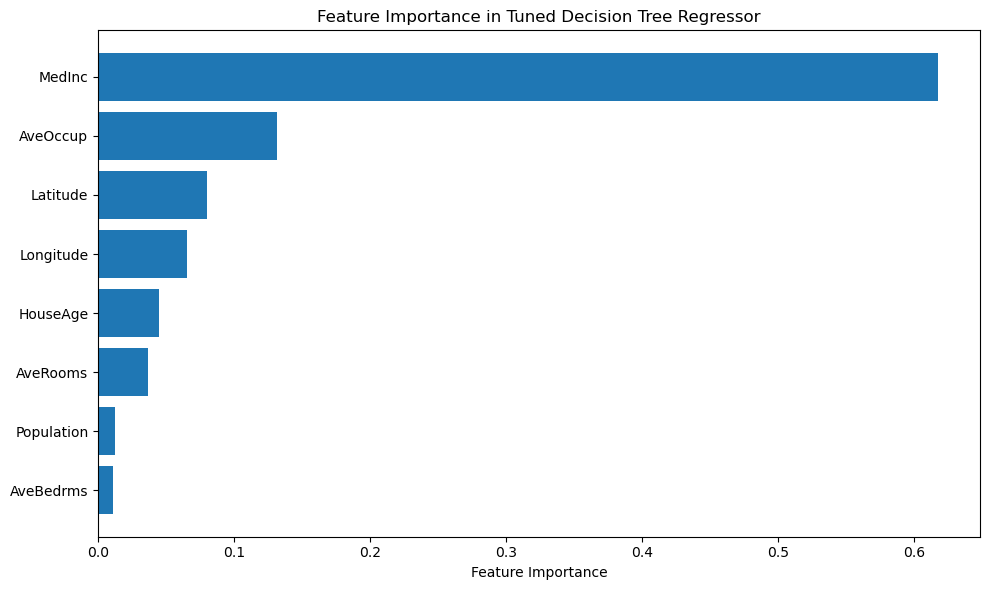

In [33]:
# Feature importance analysis
import matplotlib.pyplot as plt

feature_importance = reg.best_estimator_.feature_importances_
feature_names = X.columns

# Create feature importance DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nFeature Importance Rankings:")
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Tuned Decision Tree Regressor')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()